In [9]:
import requests
import urllib.parse

import json
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO
from wordcloud import WordCloud


# Mostrar gráficos en línea
%matplotlib inline

# Nasa API

Pedi el acceso a la api key en este link: https://api.nasa.gov/

Tan solo se necesita nombre, apellido y mail. Envian al mail la KEY

In [2]:
# API KEY
api_key = 'TmUQiGA8aMVDMeBWoxxGFmFdqvhr2gzGEIhD9BGM'
start_date = "2024-03-01"
end_date = "2024-03-15"

# Endpoint de la API de la NASA (Astronomy Picture of the Day)
url = 'https://api.nasa.gov/planetary/apod'

# Llamado a la API
url = "https://api.nasa.gov/planetary/apod"
params = {
    "api_key": api_key,
    "start_date": start_date,
    "end_date": end_date
}

response = requests.get(url, params=params)
data = response.json()

# Verificamos el tipo de respuesta
print(f"Se obtuvieron {len(data)} registros desde la API.")

Se obtuvieron 15 registros desde la API.


En el dataframe encontramos 3 columnas:
- date: la fecha en la que se subio la imagen, en formato date
- title: titulo de la imagen o video, en formato string
- media_type: tipo de contenido. Imagen o video en formato string
- url: tipo string, url de acceso al video o imagen

In [3]:
# Convertimos en DataFrame
df = pd.DataFrame(data)

# Mostramos algunas columnas
df[['date', 'title', 'media_type', 'url', 'explanation']].head()


,date,title,media_type,url,explanation
0,2024-03-01,Odysseus and The Dish,image,https://apod.nasa.gov/apod/image/2403/The_Dish...,"Murriyang, the CSIRO’s Parkes Radio Telescope,..."
1,2024-03-02,Odysseus on the Moon,image,https://apod.nasa.gov/apod/image/2403/IM_Odyss...,"Methalox rocket engine firing, Odysseus' landi..."
2,2024-03-03,A Total Solar Eclipse Close-Up in Real Time,video,https://www.youtube.com/embed/5D9j-8Vhyto?rel=...,How would you feel if the Sun disappeared? Man...
3,2024-03-04,Light Pillars Over Inner Mongolia,image,https://apod.nasa.gov/apod/image/2403/PillarsM...,What's happening across that field? Pictured ...
4,2024-03-05,NGC 2170: Angel Nebula Abstract Art,image,https://apod.nasa.gov/apod/image/2403/AngelNeb...,Is this a painting or a photograph? In this ce...


In [4]:
# Estadísticas básicas
print("Media types:", df['media_type'].value_counts())
print("Rango de fechas:", df['date'].min(), "a", df['date'].max())

Media types: media_type
image    14
video     1
Name: count, dtype: int64
Rango de fechas: 2024-03-01 a 2024-03-15


Creo una columna para ver la cantidad de palabras para la columna de explicacion. Se podria usar para un analisis de si es necesario una explicacion resumida o mas extensa

In [5]:
# Creamos columna para longitud de explicación
df['explanation_length'] = df['explanation'].apply(lambda x: len(x.split()))

In [7]:
print(df.isnull().sum())


df_cleaned = df.dropna()

copyright             2
date                  0
explanation           0
hdurl                 1
media_type            0
service_version       0
title                 0
url                   0
explanation_length    0
dtype: int64


# Porcentaje total del contenido

Tenemos dos valores posibles: imagen o video

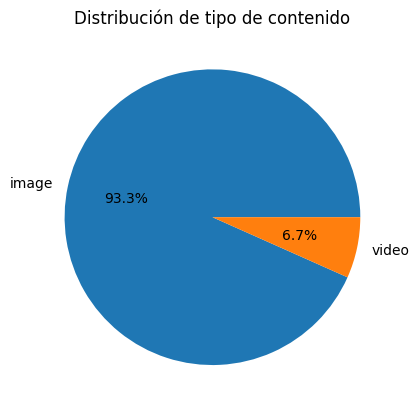

In [8]:
df['media_type'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Distribución de tipo de contenido')
plt.ylabel('')
plt.show()

# Visualizacion de la cantidad de palabras para la explicacion del contenido

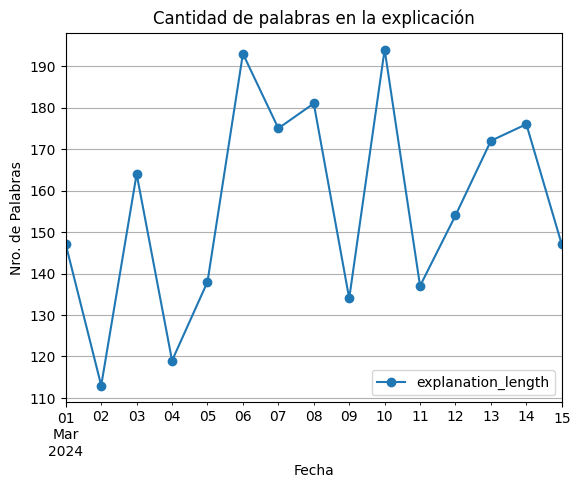

In [ ]:
df['date'] = pd.to_datetime(df['date'])

df.plot(x='date', y='explanation_length', kind='line', marker='o',
        title='Cantidad de palabras en la explicación')
plt.xlabel('Fecha')
plt.ylabel('Nro. de Palabras')
plt.grid(True)
plt.show()


# Palabras clave en los titulos

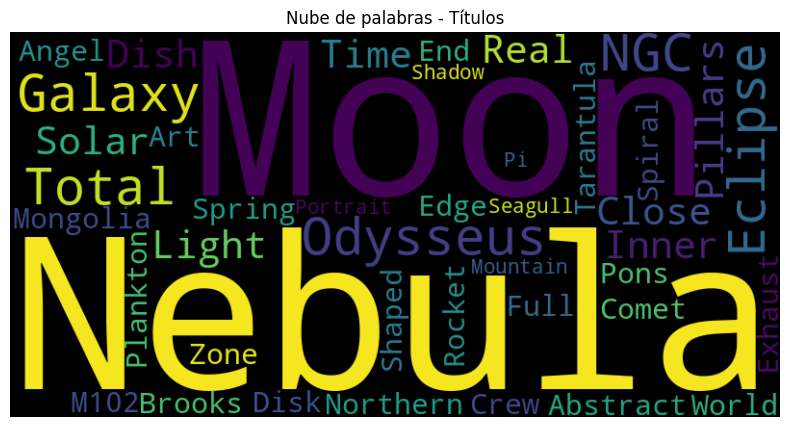

In [ ]:
text = " ".join(df['title'].tolist())
wordcloud = WordCloud(width=800, height=400, background_color='black').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de palabras - Títulos')
plt.show()


# Imagenes o Videos que podemos llegar a encontrar en el Dataframe

📅 2024-03-01 - Odysseus and The Dish


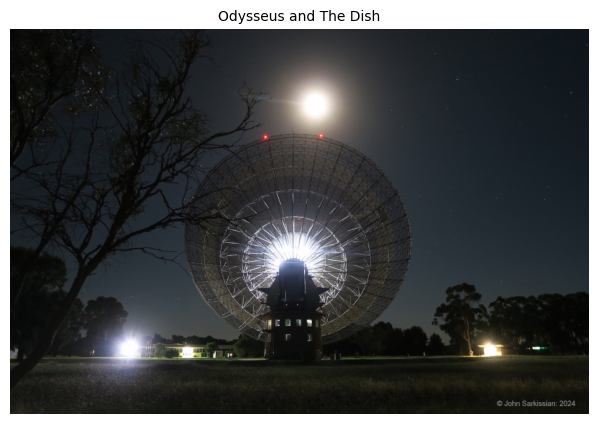

📅 2024-03-02 - Odysseus on the Moon


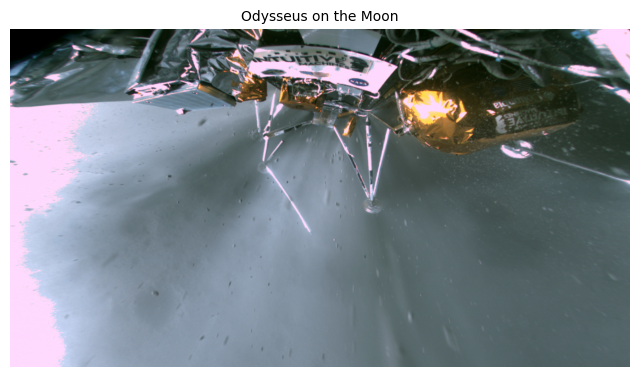

📅 2024-03-03 - A Total Solar Eclipse Close-Up in Real Time


In [ ]:
for item in data[:3]:  # Mostramos las 3 primeras imágenes
    print(f"📅 {item['date']} - {item['title']}")

    if item['media_type'] == 'image':
        img_url = item['url']
        response = requests.get(img_url)
        img = Image.open(BytesIO(response.content))

        # Mostrar con matplotlib
        plt.figure(figsize=(8, 5))
        plt.imshow(img)
        plt.axis('off')
        plt.title(item['title'], fontsize=10)
        plt.show()

In [ ]:
if item['media_type'] == 'video':
    print(f"🎥 Video disponible: {item['url']}")

# Conclusiones y Casos de uso de la API

A través del uso de la API de la NASA se pudieron obtener datos en formato semiestructurado (JSON).

Se exploraron aspectos como:
- El tipo de contenido publicado (imagen o video).
- La longitud de las explicaciones científicas.
- Los títulos más frecuentes a través de una nube de palabras.


Tenemos varias posibilidades para el uso de esta API:

1. Educación y divulgación científica

    Docentes y divulgadores pueden usar las imágenes y explicaciones para enriquecer clases sobre astronomía, física, o exploración espacial.

    Se puede generar contenido educativo automatizado diariamente a partir de la imagen y su explicación.

2. Aplicaciones móviles/web

    Desarrollo de apps que muestran la "Imagen del día", incluyendo descripciones y enlaces a material adicional.

    Sitios o widgets de ciencia y tecnología que actualizan automáticamente la imagen y el texto.

3. Análisis de contenido astronómico

    Analizar qué tipos de eventos astronómicos se publican con mayor frecuencia.

    Ver qué palabras clave se repiten (supernova, galaxia, Marte, etc.) y detectar tendencias.

4. Entrenamiento de modelos NLP o de visión computacional

    Usar los textos para tareas de procesamiento de lenguaje natural (resumen automático, detección de temas).

    Usar las imágenes como dataset para modelos de clasificación de objetos astronómicos.

5. Visualizaciones históricas

    Crear timelines interactivos de las publicaciones.

    Ver evolución de eventos astronómicos observados por la NASA a lo largo del tiempo.

6. Inspiración artística y cultural

    Material visual y descriptivo que puede ser utilizado por artistas, diseñadores o creadores de contenido para inspirarse o crear piezas basadas en el espacio.
